In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math
import sklearn.mixture as mix
import emcee
import warnings; warnings.simplefilter('ignore')
import time
import corner

In [34]:
data=np.load('transient.npy')

<ErrorbarContainer object of 3 artists>

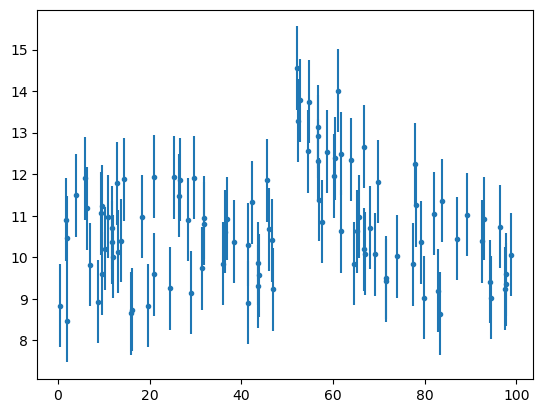

In [35]:
plt.errorbar(data[:,0],data[:,1],yerr=data[:,2],fmt='.')

# emcee

In [36]:
b = 10             #background amplitude
A = 5              #burst amplitude
t0 = 50            #burst epoch
alpha = 0.12       #how rapidly the burst dies off
p = [b,A,t0,alpha] #joint parameter space

def model(p,t):
    array = np.full_like(t,1)
    array[t<p[2]] = p[0]
    array[t>=p[2]] = p[0] + (p[1]*np.exp(-p[3]*(t[t>=p[2]]-p[2])))
    return array

def ln_likelihood(p,t):
    return -0.5*np.sum(((data[:,1]-model(p,t))**2)/data[:,2]**2)
    #return -0.5*np.sum(((data[:,1]-model(p,t))**2)/data[:,2]**2 + np.log(2*np.pi*data[:,2]**2))
    #good to assume all gaussianly distributed because of the central limit theorem

def prior(p):
    if p[3] <= 0:
        return 0
    prior_b = stats.uniform.pdf(p[0], loc=0, scale=50)
    prior_A = stats.uniform.pdf(p[1], loc=0, scale=50)
    prior_t0 = stats.uniform.pdf(p[2], loc=0, scale=100)
    prior_lnalpha = stats.uniform.pdf(np.log(p[3]), loc=-5, scale=10)*(1/p[3])
    if prior_b*prior_A*prior_t0*prior_lnalpha == 0:
        return 0
    else:
        return prior_b*prior_A*prior_t0*prior_lnalpha
    

def posterior(p,t):
    return np.exp(ln_likelihood(p,t))*(prior(p))

def log_posterior(p,t):
    lp = np.log(prior(p))
    if not np.isfinite(lp):
        return -np.inf
    if not np.isfinite(ln_likelihood(p,t)):
        return -np.inf
    else:
        return ln_likelihood(p,t)+lp

In [37]:
ndim = 4         # number of parameters in the model
nwalkers = 10    # number of MCMC walkers
burn = 10000     # "burn-in" period to let chains stabilize
nsteps = 100000  # number of MCMC steps to take **for each walker**

# initialize parameters 
np.random.seed(0)
starting_guesses = np.array([b,A,t0,alpha])+1e-3*np.random.random((nwalkers, ndim))

# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[data[:,0]])
elapsed=time.time()
sampler.run_mcmc(starting_guesses, nsteps)
print(time.time()-elapsed)

# sampler.chain is of shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape:
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

print("done")

482.46347880363464
done


Shape di samples: (90000, 10, 4)


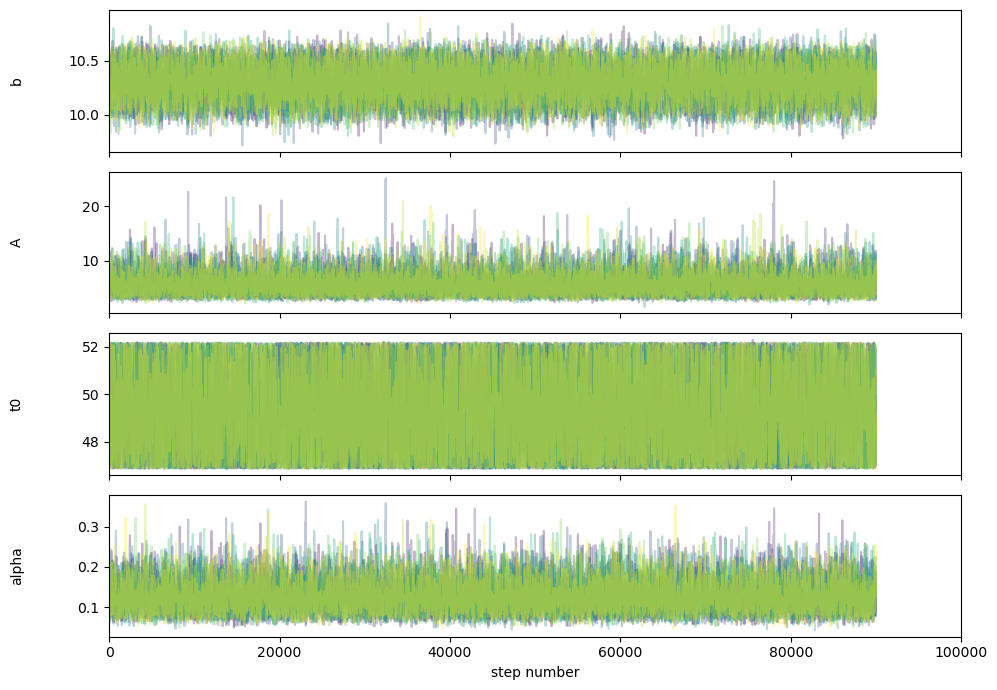

In [38]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain(discard=burn)
print(f"Shape di samples: {samples.shape}")
labels = ["b","A","t0","alpha"]
colors = plt.cm.viridis(np.linspace(0, 1, nwalkers))

for i in range(ndim):
    ax = axes[i]
    for j in range(nwalkers):
        ax.plot(samples[:, j, i], color=colors[j], alpha=0.3)
    ax.set_xlim(0, nsteps)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")
plt.tight_layout()
plt.show()

In [39]:
tau = sampler.get_autocorr_time()
print(tau)

[68.46210945 90.12264278 88.41667552 75.00281934]


(10000, 4)


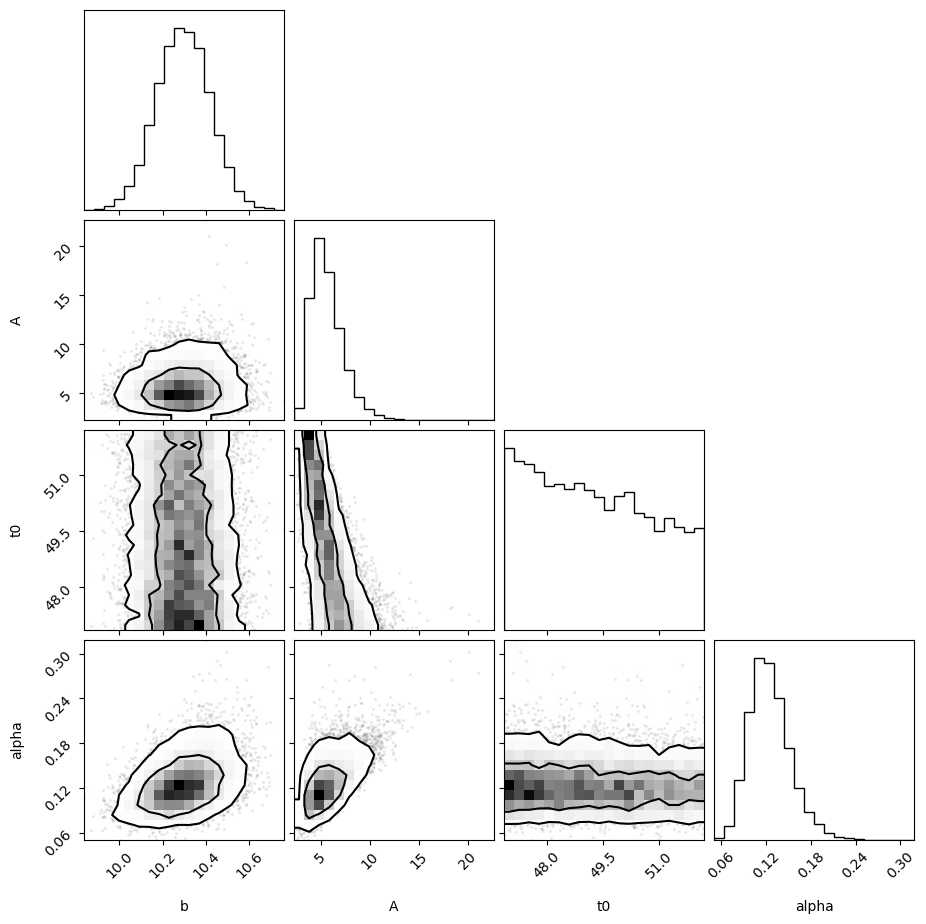

In [40]:
flat_samples = sampler.get_chain(discard=burn, thin=int(np.max(tau)), flat=True)
print(flat_samples.shape)
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95])

[10.293923974838375, 5.393691639740653, 49.137961110112286, 0.1220992683641424]


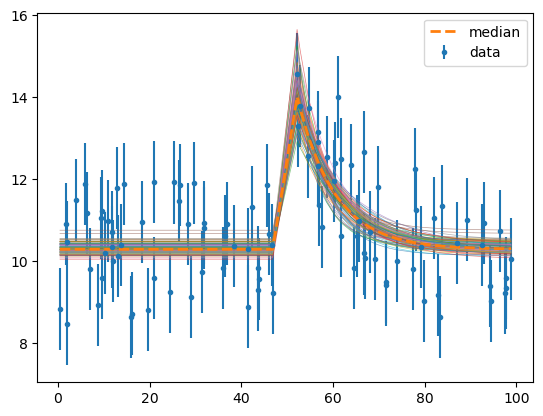

In [41]:
samp100 = flat_samples[np.random.choice(len(flat_samples), size=100)]
plt.errorbar(data[:,0],data[:,1],yerr=data[:,2],fmt='.',label='data')

for i in range(len(samp100)):
    y = model(samp100[i],data[:,0])
    plt.plot(data[:,0],y,alpha=0.6,lw=0.5)

medians = []
for i in range(len(flat_samples[0,:])):
    medians.append(np.median(flat_samples[:,i]))
print(medians)

plt.plot(data[:,0],model(medians,data[:,0]),'--',lw=2,label='median')
plt.legend()
plt.show()

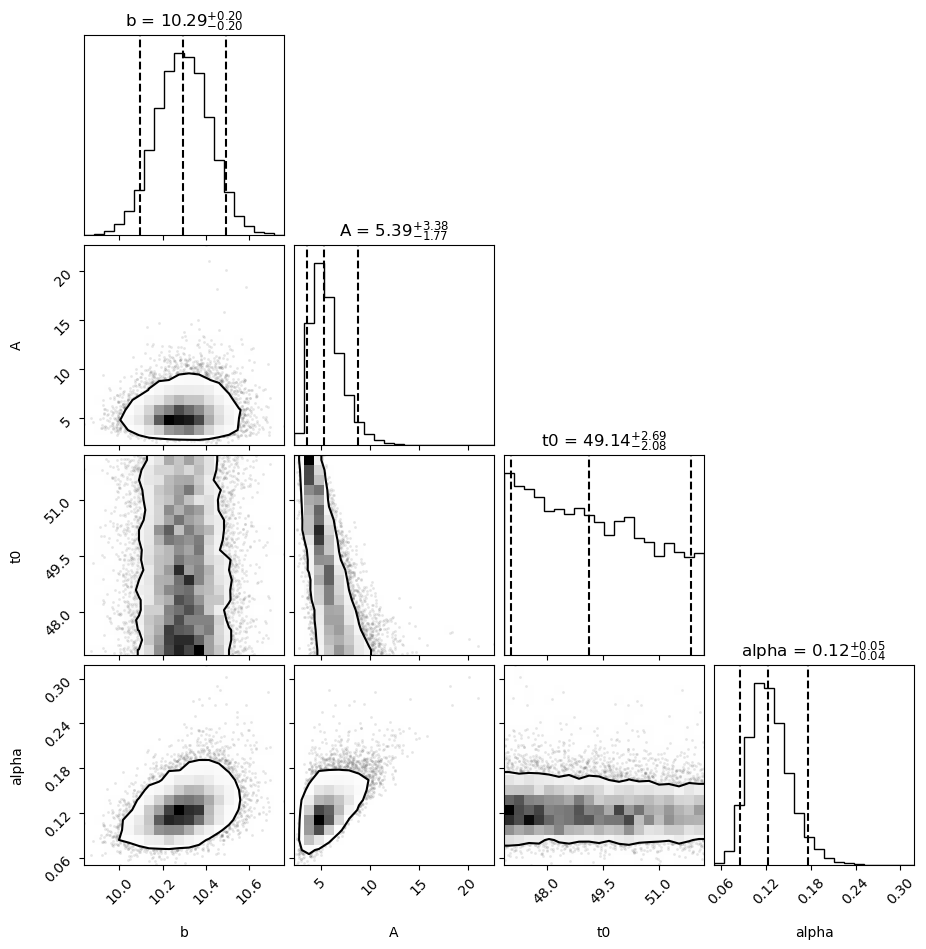

In [42]:
fig = corner.corner(flat_samples, labels=labels, levels=[0.90],
                    quantiles=[0.05,0.5,0.95], show_titles=True, title_kwargs={'fontsize':12})

# With Nested Sampling

In [43]:
time = data[:,0]
flux = data[:,1]
fluxerr = data[:,2]

def model_2(p2):
    t = time
    array = np.full_like(t,1)
    array[t<p2[2]] = p2[0]
    array[t>=p2[2]] = p2[0] + (p2[1]*np.exp(-(np.exp(p2[3]))*(t[t>=p2[2]]-p2[2]))) #p[3] è log_alpha!!
    return array

def ln_likelihood_2(p2):
    t = time
    #NEED TO BE NORMALIZED
    return -0.5*np.sum(((flux-model_2(p2))**2)/(fluxerr)**2 + np.log(2*np.pi*(fluxerr)**2))
    #good to assume all gaussianly distributed because of the central limit theorem

def prior_2(p2):
    if p2[3] <= 0:
        return 0
    prior_b = 50*p2[0]
    prior_A = 50*p2[1]
    prior_t0 = 100*p2[2]
    prior_lnalpha = 5*(2*p2[3] - 1) #p[3] è log_alpha
    return [prior_b,prior_A,prior_t0,prior_lnalpha]
    

def posterior_2(p2,t):
    return np.exp(ln_likelihood_2(p2,t))*(prior_2(p2))

def log_posterior_2(p2,t):
    lp_2 = np.log(prior_2(p2))
    if not np.isfinite(lp_2):
        return -np.inf
    if not ln_likelihood_2(p2,t):
        return -np.inf
    else:
        return ln_likelihood_2(p2,t)+lp_2

In [44]:
import dynesty
from dynesty import plotting as dyplot
sampler2 = dynesty.NestedSampler(ln_likelihood_2, prior_2, ndim)
sampler2.run_nested()
sresults2 = sampler2.results

7688it [01:00, 126.50it/s, +500 | bound: 157 | nc: 1 | ncall: 135400 | eff(%):  6.070 | loglstar:   -inf < -140.655 <    inf | logz: -155.240 +/-  0.168 | dlogz:  0.001 >  0.509]


In [45]:
sresults2.summary()

Summary
nlive: 500
niter: 7688
ncall: 134900
eff(%):  6.070
logz: -155.240 +/-  0.298


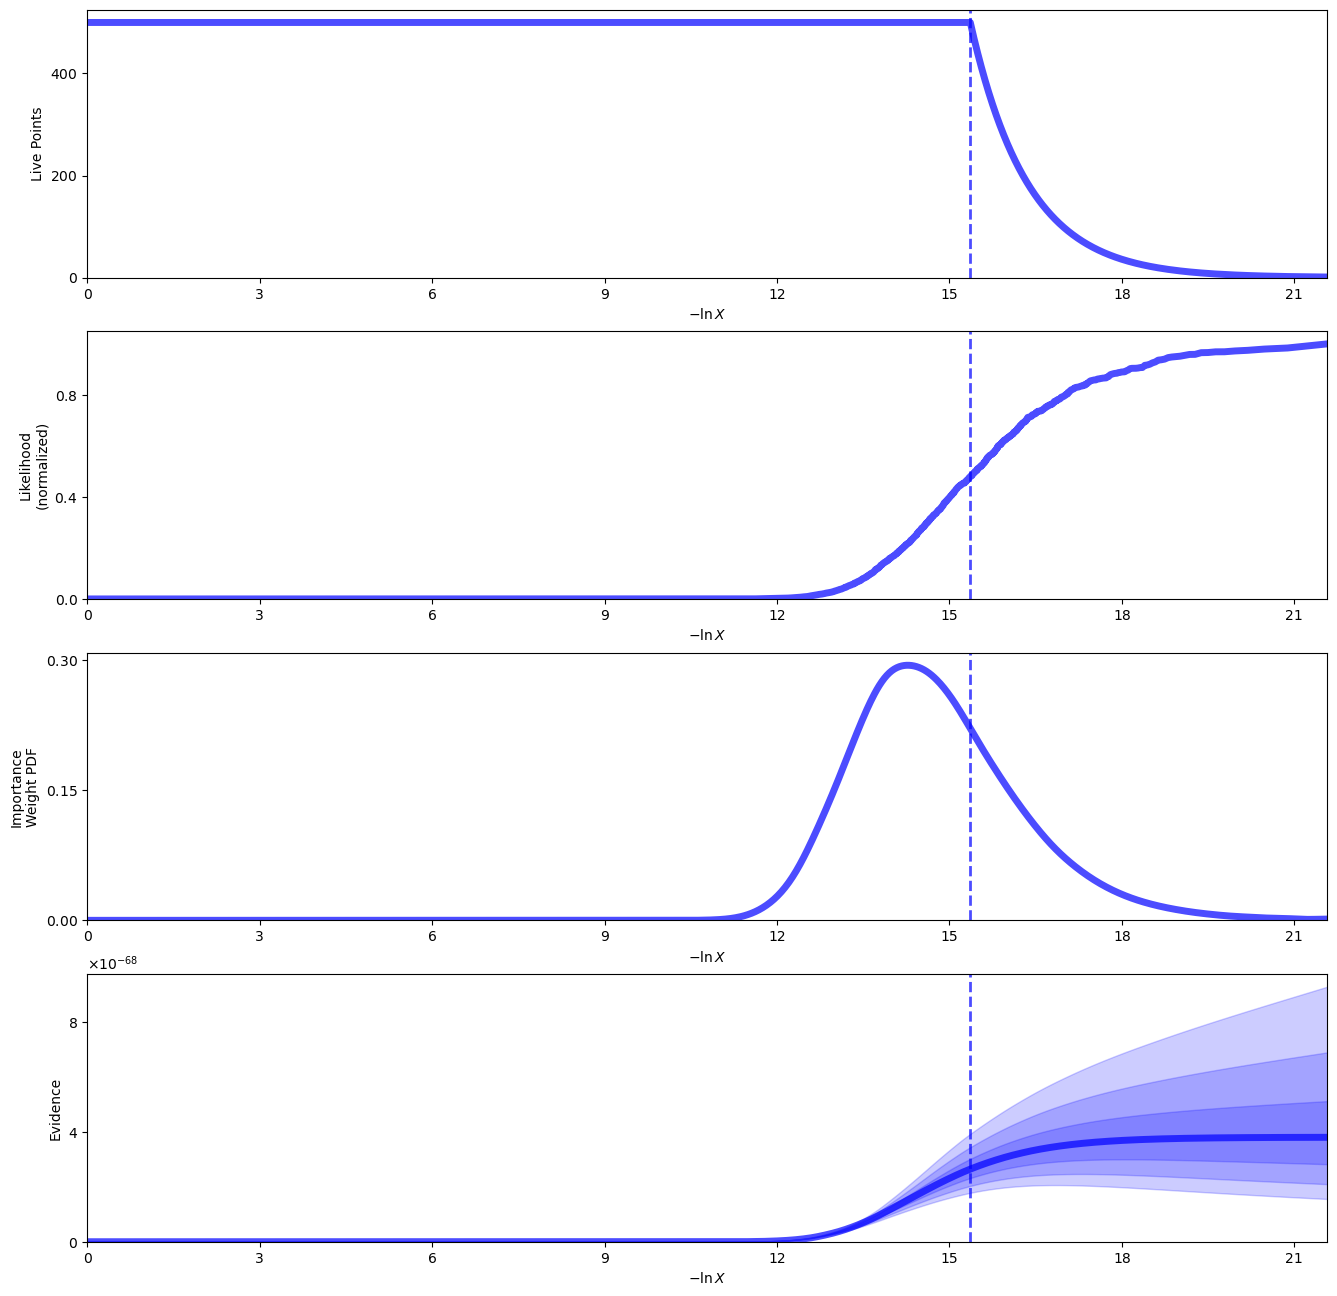

In [46]:
rfig, raxes = dyplot.runplot(sresults2)

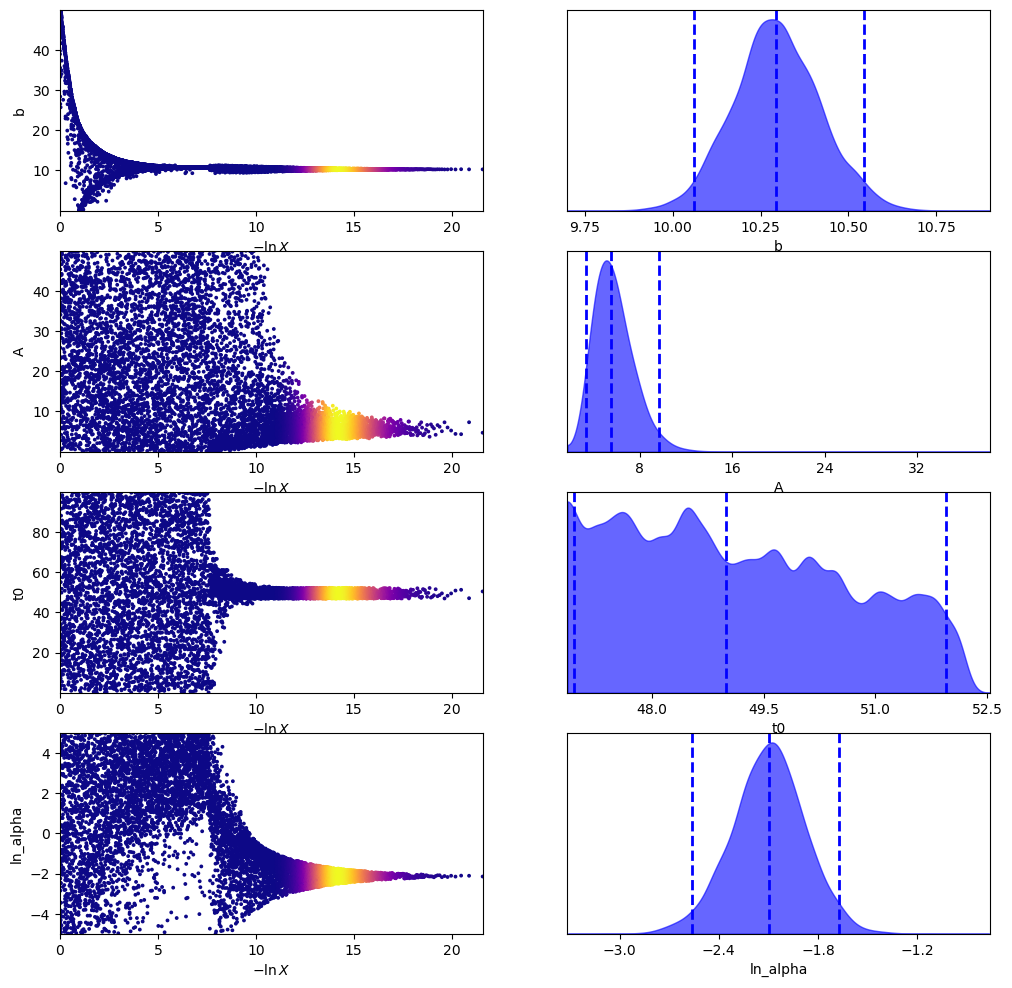

In [47]:
tfig, taxes = dyplot.traceplot(sresults2, labels=['b','A','t0','ln_alpha'])

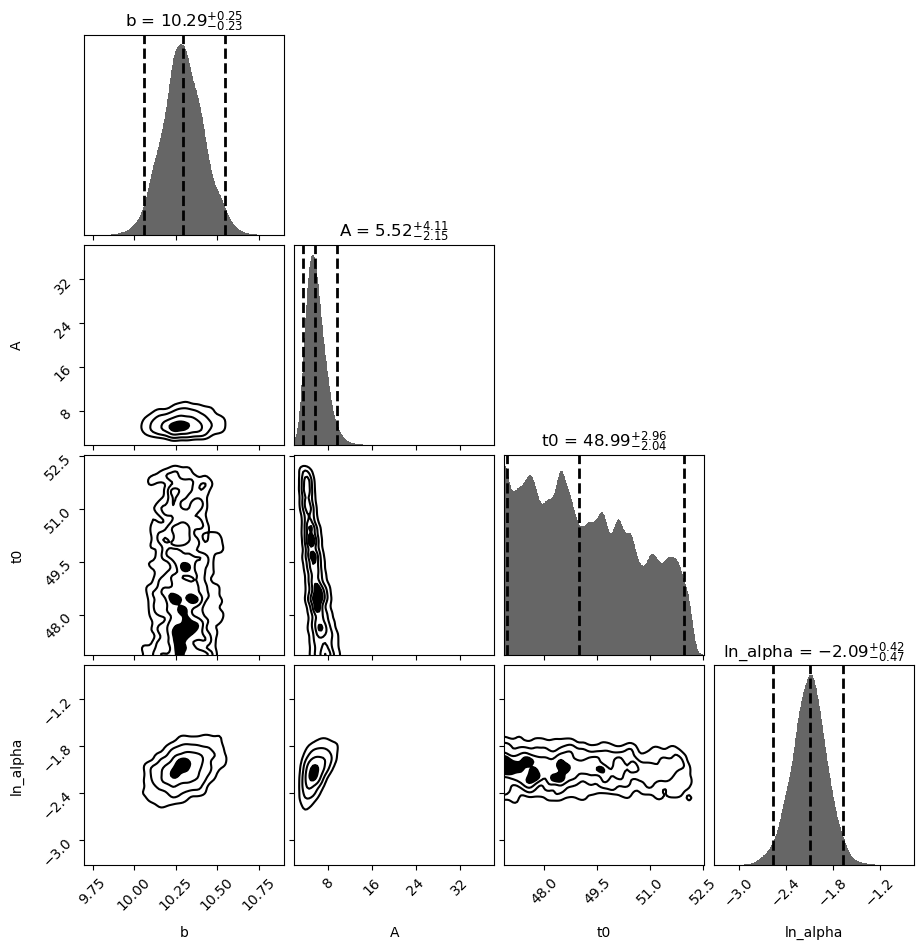

In [49]:
cfig, caxes = dyplot.cornerplot(sresults2, labels=['b','A','t0','ln_alpha'], show_titles=True)

## Gaussian Model

In [52]:
def model3(p):
    t=time
    return p[0] + (p[1]*np.exp(-((t-p[2])**2)/(2*(np.exp(p[3]))**2)))
    #p[0]=b, p[1]=A, p[2]=t0, p[3]=ln_sigma

def prior3(p):
    prior_b = 50*p[0]
    prior_A = 50*p[1]
    prior_t0 = 100*p[2]
    prior_lnsigma = 5*(2*p[3] - 1) #p[3] è log_sigma
    return [prior_b,prior_A,prior_t0,prior_lnsigma]

def ln_likelihood3(p):
    t = time
    #NEED TO BE NORMALIZED, already normalized(top)
    return -0.5*np.sum(((flux-model3(p))**2)/(fluxerr)**2 + np.log(2*np.pi*(fluxerr)**2))
    #good to assume all gaussianly distributed because of the central limit theorem

In [51]:
import dynesty
from dynesty import plotting as dyplot
sampler3 = dynesty.NestedSampler(ln_likelihood3, prior3, ndim)
sampler3.run_nested()
sresults3 = sampler3.results

8585it [01:00, 141.18it/s, +500 | bound: 177 | nc: 1 | ncall: 150918 | eff(%):  6.040 | loglstar:   -inf < -144.329 <    inf | logz: -160.767 +/-  0.181 | dlogz:  0.001 >  0.509]


In [54]:
sresults3.summary()

Summary
nlive: 500
niter: 8585
ncall: 150418
eff(%):  6.040
logz: -160.767 +/-  0.314


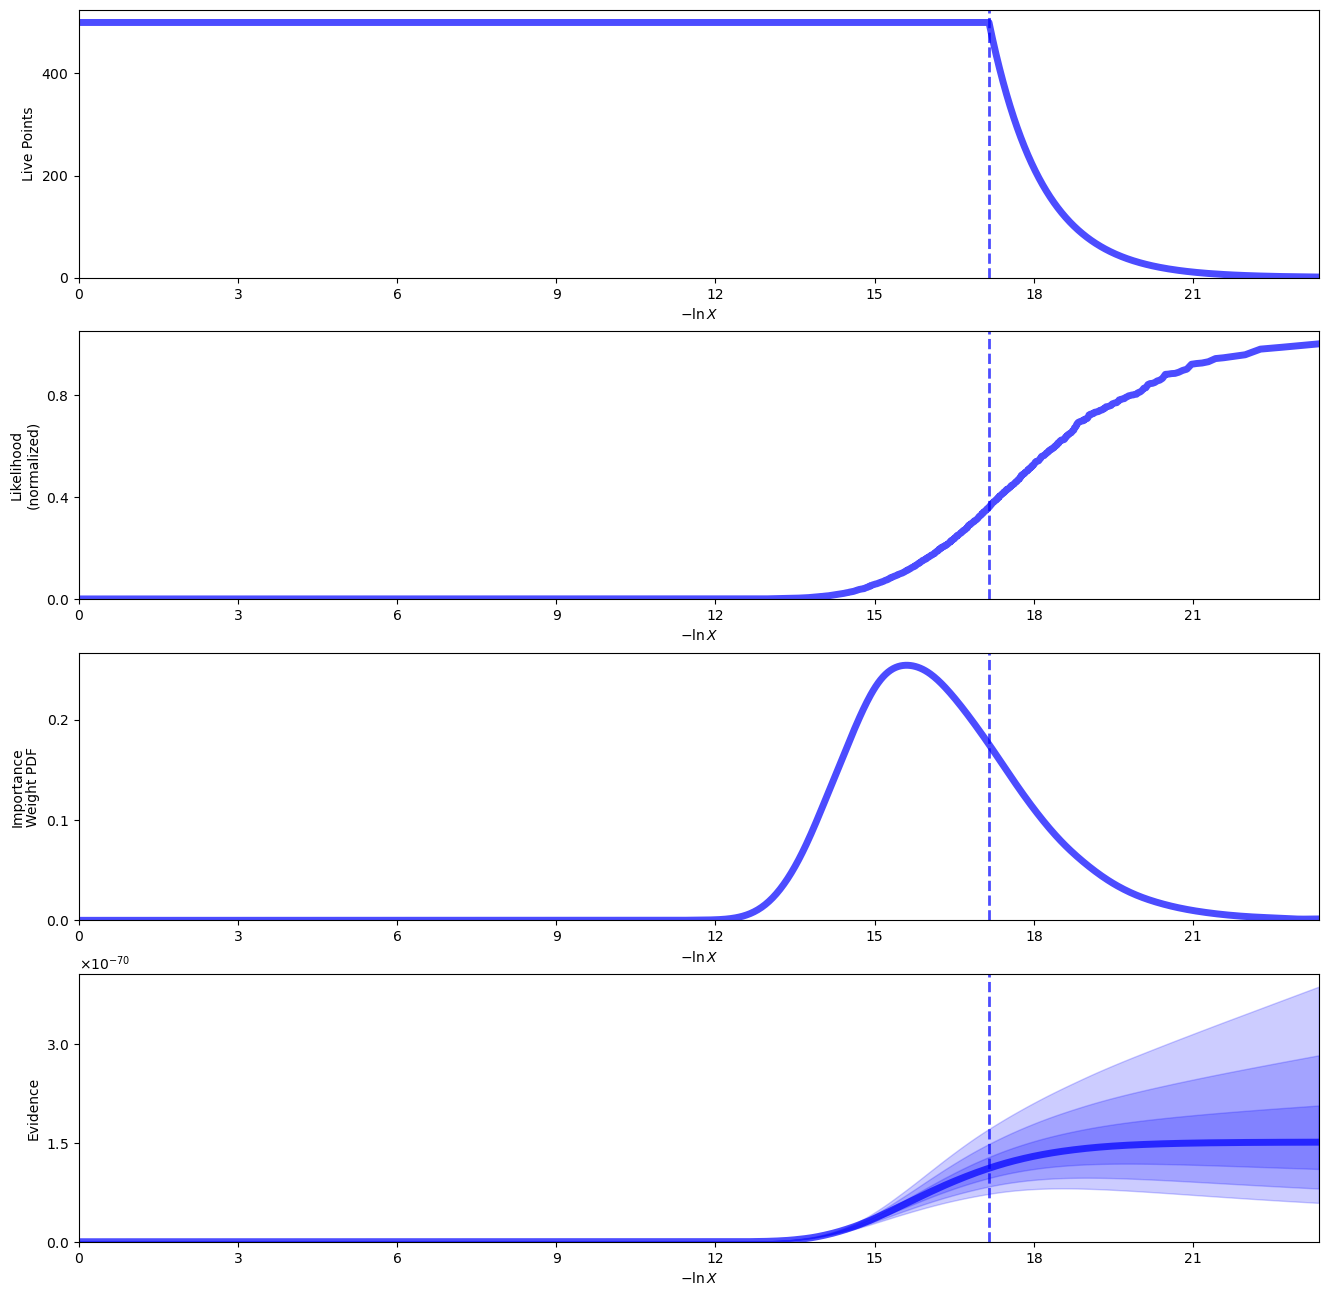

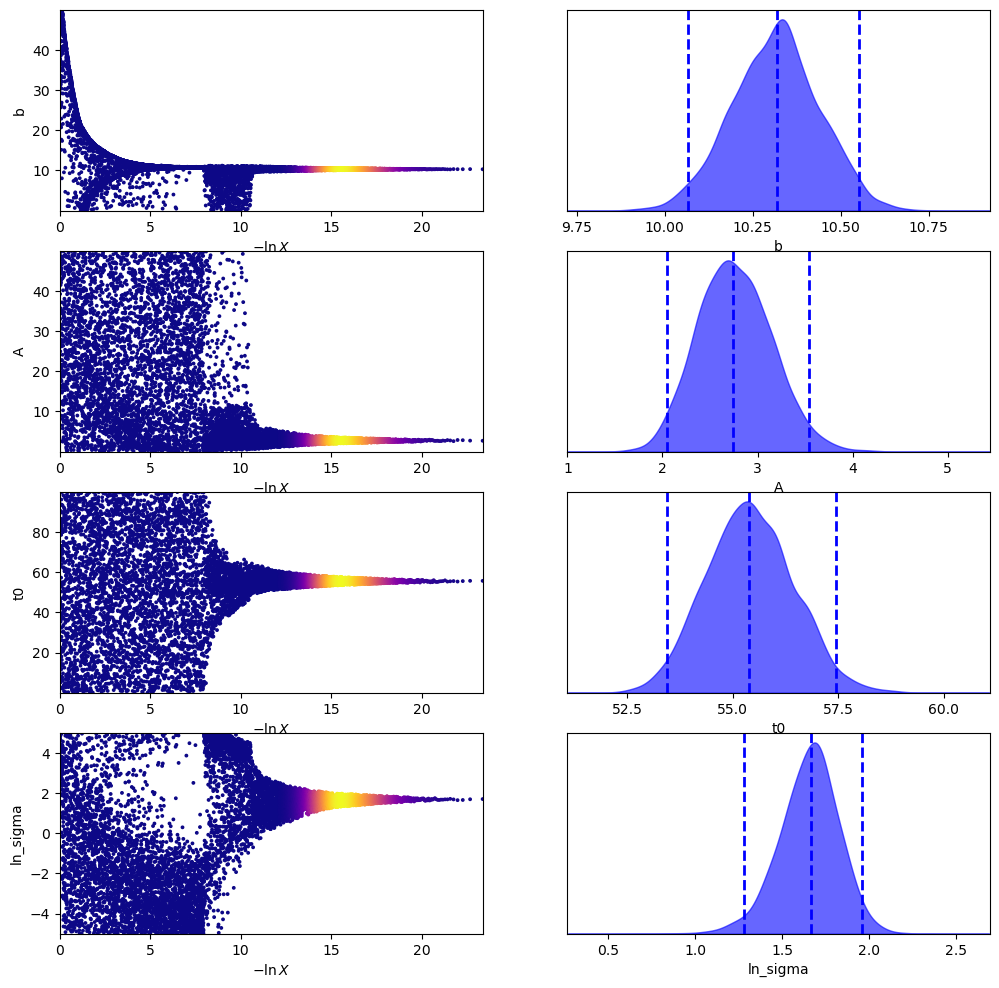

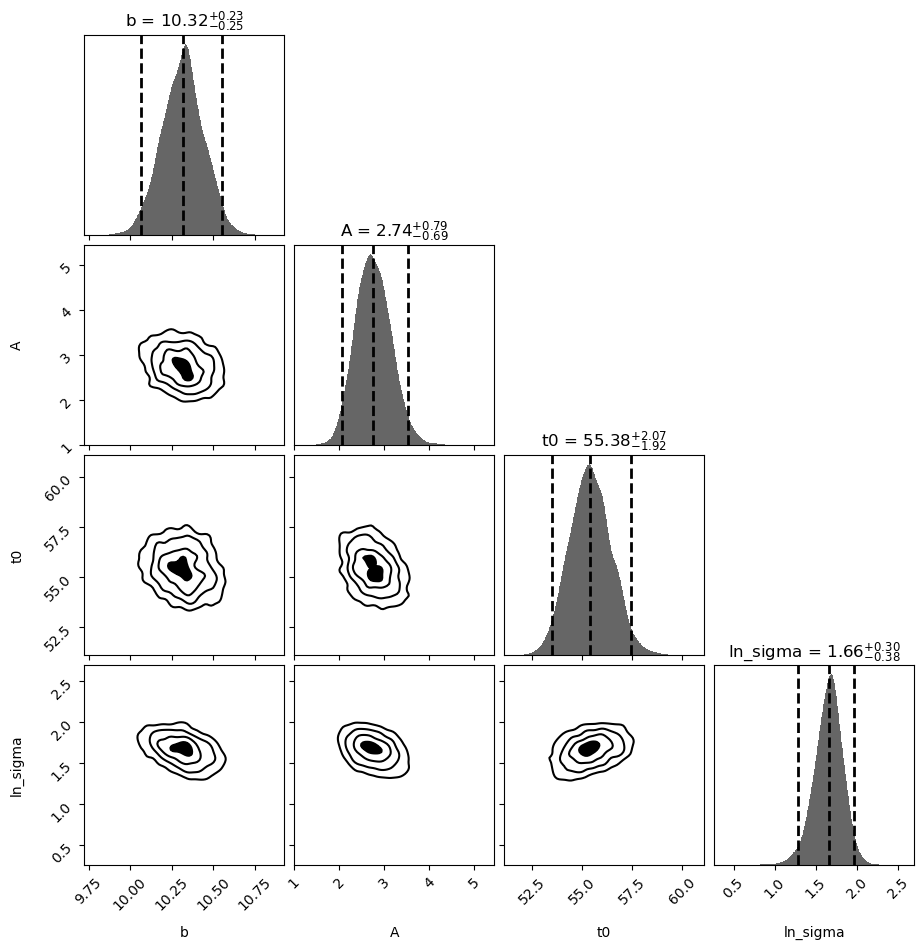

In [53]:
rfig, raxes = dyplot.runplot(sresults3)
tfig, taxes = dyplot.traceplot(sresults3, labels=['b', 'A', 't0', 'ln_sigma'])
cfig, caxes = dyplot.cornerplot(sresults3, labels=['b', 'A', 't0', 'ln_sigma'], show_titles=True)

# Bayesian Evidence and Bayes Factor

In [56]:
be_m2 = np.exp(sresults2.logz[-1])
be_m3 = np.exp(sresults3.logz[-1])
print('Bayesian evidence of model 2:', be_m2, '\n', 'Bayesian evidence of model 3:', be_m3)

#Jeffrey's scale (odd ratio, since the two models have the same number of hyperpriors?)
b = be_m2/be_m3
print('Bayes Factor = ', b)

Bayesian evidence of model 2: 3.804374702044296e-68 
 Bayesian evidence of model 3: 1.513214034526203e-70
Bayes Factor =  251.41021793625316


Since it is > 100, we have stronge evidence that the first considered model (model 2) is better than the gaussian model(model 3)